# 01 - Backtesting: Media Móvil Simple con Filtro Sectorial

**Capítulo**: 01 - Media Móvil

**Objetivo**: Evaluar la estrategia de filtro sectorial + SMA(30) con backtesting.py y reportar métricas.

---

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
from backtesting import Backtest, Strategy
from backtesting.lib import crossover

from curso.lib.data import download_historical
from curso.lib.indicators import sma
from curso.lib.backtest import run_backtest, extract_metrics, metrics_to_dataframe
from curso.lib.reporting import plot_equity_curve, plot_drawdown, print_metrics_table

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup completado ✓')

/Users/rolmov/Documents/github/sdd-project/.venv/lib/python3.12/site-packages/backtesting/_plotting.py:50: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support (e.g. PyCharm, Spyder IDE). Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

Setup completado ✓


## 2. Datos

In [2]:
# Usamos JNJ como activo principal para el backtest
TICKER = "JNJ"
df = download_historical(TICKER)
print(f"{TICKER}: {len(df)} registros ({df.index.min().date()} → {df.index.max().date()})")
df.head()

JNJ: 1254 registros (2021-06-01 → 2026-05-28)


,Open,High,Low,Close,Volume
date,,,,,
2021-06-01,170.149994,170.199997,165.380005,165.529999,10448400
2021-06-02,165.300003,166.729996,165.110001,166.199997,6806000
2021-06-03,165.889999,167.149994,165.710007,166.039993,5808800
2021-06-04,167.009995,167.570007,165.869995,165.970001,6510300
2021-06-07,166.000000,166.320007,164.630005,164.839996,5362800


## 3. Definir la estrategia para backtesting.py

Adaptamos la lógica de `spec.md` al formato de backtesting.py.

In [3]:
def SMA_indicator(values, n):
    """Calcula SMA como función compatible con backtesting.py."""
    return pd.Series(values).rolling(n).mean().values


class SMAFilterStrategy(Strategy):
    """Estrategia de filtro SMA para sector salud (spec.md cap-01)."""
    
    sma_period = 30       # Período de la SMA
    days_below = 30       # Días consecutivos por debajo para señal
    stop_loss_pct = 10    # Stop-loss en %
    
    def init(self):
        self.sma = self.I(SMA_indicator, self.data.Close, self.sma_period)
        self.consecutive_below = 0
    
    def next(self):
        price = self.data.Close[-1]
        sma_val = self.sma[-1]
        
        # Contar días consecutivos por debajo de SMA
        if price < sma_val:
            self.consecutive_below += 1
        else:
            self.consecutive_below = 0
        
        # Señal de entrada
        if not self.position:
            if self.consecutive_below >= self.days_below:
                self.buy(sl=price * (1 - self.stop_loss_pct / 100))
        
        # Señal de salida
        elif self.position:
            if price > sma_val:
                self.position.close()

print('Estrategia definida ✓')

Estrategia definida ✓


## 4. Ejecutar Backtest

In [4]:
# Ejecutar backtest con parámetros de spec.md
stats, bt = run_backtest(
    data=df,
    strategy_class=SMAFilterStrategy,
    cash=10_000,
    commission=0.002,
)

# Extraer métricas estándar del curso
metrics = extract_metrics(stats)
metrics_df = metrics_to_dataframe(metrics)
print_metrics_table(metrics_df)

  RESUMEN DE BACKTESTING
  Retorno Total (%)............. 2.85
  Retorno Anualizado (%)........ 0.57
  Sharpe Ratio.................. 0.109
  Sortino Ratio................. 0.158
  Max Drawdown (%).............. -9.05
  Nº Operaciones................ 7
  Win Rate (%).................. 57.14
  Profit Factor................. 1.501
  Buy & Hold (%)................ 39.43


## 5. Visualización: Equity Curve y Drawdown

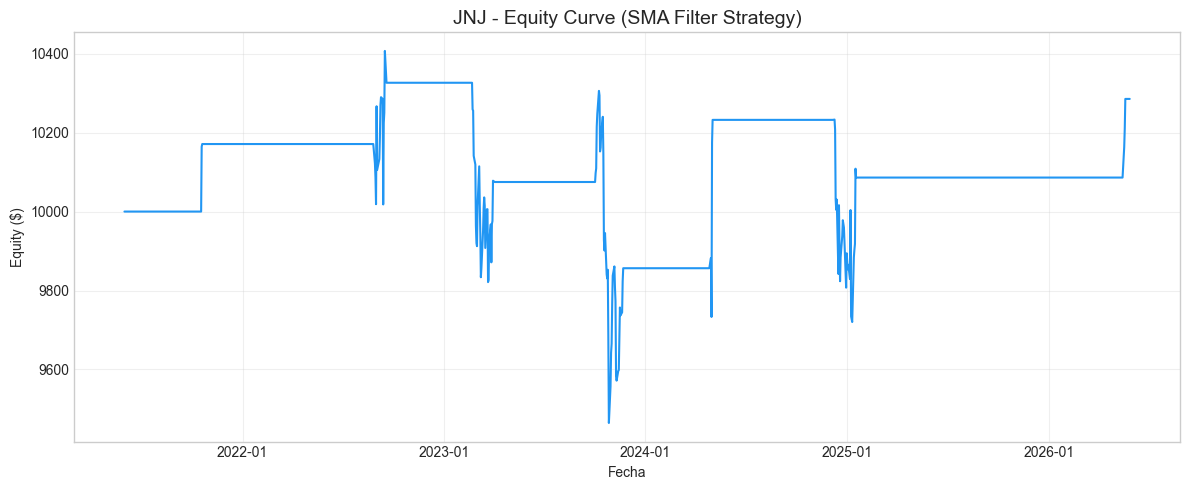

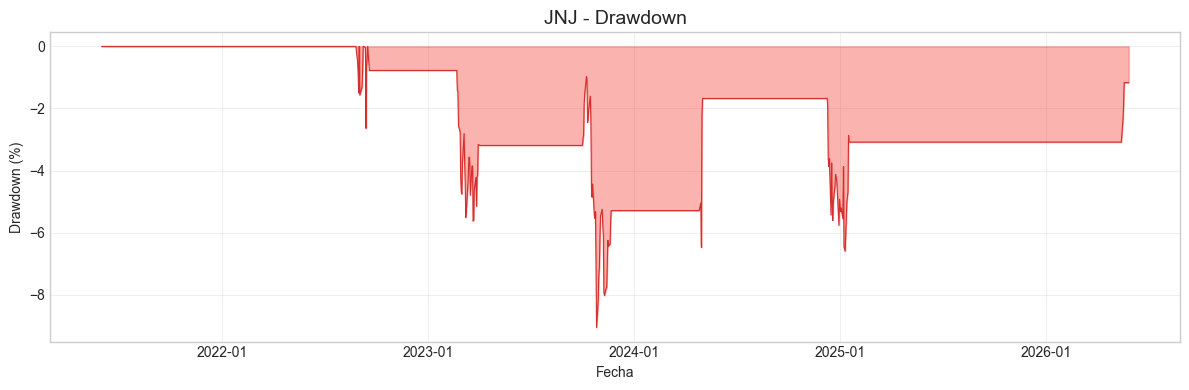

In [5]:
# Equity Curve
fig = plot_equity_curve(stats, title=f'{TICKER} - Equity Curve (SMA Filter Strategy)')
plt.show()

# Drawdown
fig = plot_drawdown(stats, title=f'{TICKER} - Drawdown')
plt.show()

## 6. Plot interactivo de backtesting.py

In [6]:
# Gráfico interactivo completo (Bokeh)
bt.plot()

ValueError: failed to validate DatetimeTickFormatter(id='p1055', ...).days: expected a value of type str, got ['%d %b', '%a %d'] of type list

## 7. Comparación vs Buy & Hold

In [7]:
print("=" * 50)
print("  COMPARACIÓN: Estrategia vs Buy & Hold")
print("=" * 50)
print(f"  Retorno Estrategia:    {metrics.retorno_total_pct:.2f}%")
print(f"  Retorno Buy & Hold:    {metrics.buy_and_hold_pct:.2f}%")
print(f"  Diferencia:            {metrics.retorno_total_pct - metrics.buy_and_hold_pct:.2f}%")
print(f"  Max Drawdown Estrat.:  {metrics.max_drawdown_pct:.2f}%")
print("=" * 50)

if metrics.retorno_total_pct > metrics.buy_and_hold_pct:
    print("\n✅ La estrategia SUPERA a Buy & Hold en retorno total.")
else:
    print("\n⚠️ Buy & Hold supera a la estrategia en retorno total.")
    print("   (Esto es común — el valor puede estar en menor drawdown o mejor Sharpe)")

  COMPARACIÓN: Estrategia vs Buy & Hold
  Retorno Estrategia:    2.85%
  Retorno Buy & Hold:    39.43%
  Diferencia:            -36.58%
  Max Drawdown Estrat.:  -9.05%

⚠️ Buy & Hold supera a la estrategia en retorno total.
   (Esto es común — el valor puede estar en menor drawdown o mejor Sharpe)


## 8. Conclusiones y Decisión

In [8]:
print("""
CONCLUSIONES DEL BACKTEST
========================

1. Rendimiento: [Interpretar resultado vs buy & hold]

2. Riesgo: [Evaluar max drawdown vs tolerancia del 15%]

3. Sharpe Ratio: [Evaluar si > 0.5 como target de spec.md]

4. Limitaciones observadas:
   - Pocas señales de entrada (estrategia conservadora)
   - Sensible al período elegido de SMA y días consecutivos
   - No considera costes de oportunidad mientras espera señal

5. DECISIÓN: [aprobar / iterar / descartar]
   
   Justificación: [Explicar la decisión basándose en métricas]
""")


CONCLUSIONES DEL BACKTEST

1. Rendimiento: [Interpretar resultado vs buy & hold]

2. Riesgo: [Evaluar max drawdown vs tolerancia del 15%]

3. Sharpe Ratio: [Evaluar si > 0.5 como target de spec.md]

4. Limitaciones observadas:
   - Pocas señales de entrada (estrategia conservadora)
   - Sensible al período elegido de SMA y días consecutivos
   - No considera costes de oportunidad mientras espera señal

5. DECISIÓN: [aprobar / iterar / descartar]

   Justificación: [Explicar la decisión basándose en métricas]



## Resumen

En este notebook hemos:

1. ✅ Definido la estrategia en formato backtesting.py
2. ✅ Ejecutado el backtest sobre datos históricos de JNJ
3. ✅ Extraído métricas estándar del curso
4. ✅ Visualizado equity curve y drawdown
5. ✅ Comparado contra Buy & Hold
6. ✅ Documentado conclusiones y decisión

---

**Siguiente paso**: Avanza al Capítulo 02 para aprender la estrategia de Cruce de Medias Móviles.